##Задача
* Найти или сгенерировать набор данных для бинарной классификации графов.
* Реализовать функцию shortest_path_kernel(train_graphs, test_graphs), которая принимает тренировочный и тестовые наборы, а возвращает пару K_train, K_test
  * Опишите графы с помощью вектора из количества кратчайших путей различной длины
  * Для вычисления длин кратчайших путей можно использовать nx.shortest_path_length(G)
  * Ядровая функция для сравнения двух графов - скалярное произведение их двух векторов
  * K_train - матрица из ядровых функций для сравнения тренировочных графов между собой
  * K_test - матрица из ядровых функций для сравнения тестовых графов с тренировочными
* Используя реализованное ядро обучите модель SVC, подберите гиперпараметры, вычислите различные метрики качества
* (+5 баллов) Также реализовать Weisfeiler-Lehman Kernel и обучить классификатор с ним, сравнить результаты.

## Датасет

Всего сгенерировано графов: 200
Класс 0 (Erdos-Renyi): 100 графов, среднее число ребер: 161.15
Класс 1 (Barabasi-Albert): 100 графов, среднее число ребер: 144.00


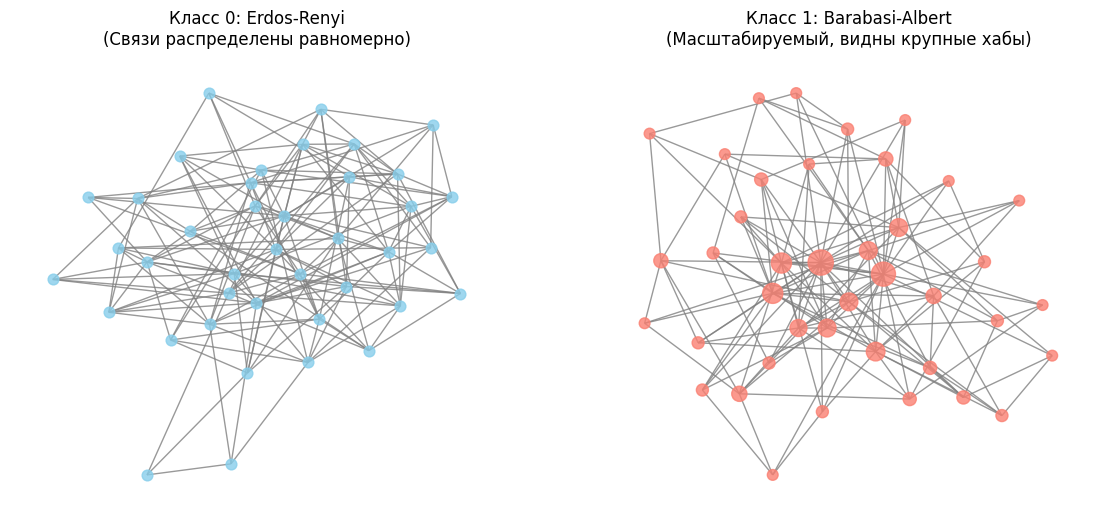

In [19]:
import random
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def generate_structural_dataset(num_graphs_per_class=300, num_nodes=40):
    graphs = []
    labels = []

    m_ba = 4  # Количество ребер для новых вершин в Barabasi-Albert
    p_er = (2 * m_ba) / (
        num_nodes - 1
    )

    for _ in range(num_graphs_per_class):
        # Класс 0: Erdos-Renyi (Случайный граф)
        while True:
            G0 = nx.erdos_renyi_graph(
                n=num_nodes, p=p_er, seed=random.randint(0, 100000)
            )
            if nx.is_connected(G0):
                break

        # Класс 1: Barabasi-Albert (Безмасштабный граф с хабами)
        while True:
            G1 = nx.barabasi_albert_graph(
                n=num_nodes, m=m_ba, seed=random.randint(0, 100000)
            )
            if nx.is_connected(G1):
                break

        graphs.append(G0)
        labels.append(0)

        graphs.append(G1)
        labels.append(1)

    return graphs, np.array(labels)

num_nodes = 40
graphs, labels = generate_structural_dataset(
    num_graphs_per_class=100, num_nodes=num_nodes
)

edges_c0 = [graphs[i].number_of_edges() for i in range(len(labels)) if labels[i] == 0]
edges_c1 = [graphs[i].number_of_edges() for i in range(len(labels)) if labels[i] == 1]

print(f"Всего сгенерировано графов: {len(graphs)}")
print(
    f"Класс 0 (Erdos-Renyi): {sum(labels == 0)} графов, среднее число ребер: {np.mean(edges_c0):.2f}"
)
print(
    f"Класс 1 (Barabasi-Albert): {sum(labels == 1)} графов, среднее число ребер: {np.mean(edges_c1):.2f}"
)

train_graphs, test_graphs, y_train, y_test = train_test_split(
    graphs, labels, test_size=0.2, random_state=RANDOM_SEED, stratify=labels
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

idx_0 = np.where(labels == 0)[0][0]
nx.draw_spring(
    graphs[idx_0],
    ax=axes[0],
    node_size=60,
    node_color="skyblue",
    edge_color="gray",
    alpha=0.8,
)
axes[0].set_title("Класс 0: Erdos-Renyi\n(Связи распределены равномерно)")

idx_1 = np.where(labels == 1)[0][0]
# Посчитаем степени вершин, чтобы подсветить хабы размером
degrees = [graphs[idx_1].degree(n) * 15 for n in graphs[idx_1].nodes()]
nx.draw_spring(
    graphs[idx_1],
    ax=axes[1],
    node_size=degrees,
    node_color="salmon",
    edge_color="gray",
    alpha=0.8,
)
axes[1].set_title("Класс 1: Barabasi-Albert\n(Масштабируемый, видны крупные хабы)")

plt.show()

## Построение матриц из ядровых функций

Преобразуем список графов в матрицу признаков (векторов кратчайших путей)

In [20]:
def compute_sp_vectors(graphs, max_path_len):
    vectors = []

    for G in graphs:
        dist_counts = np.zeros(max_path_len + 1)

        for source, dist_dict in nx.shortest_path_length(G):
            for target, dist in dist_dict.items():
                # Чтобы не считать путь (A -> B) и (B -> A) дважды, берем только source <= target
                # (Путь от вершины к самой себе при source == target учитывается один раз, длина 0)
                if source <= target:
                    if dist <= max_path_len:
                        dist_counts[dist] += 1
                    else:
                        # На случай, если в тест попал путь длиннее, чем max_path_len из трейна
                        dist_counts[-1] += 1

        vectors.append(dist_counts)

    return np.array(vectors)

Вычисляем ядерные матрицы `K_train` и `K_test` на основе кратчайших путей

Максимальная длина кратчайшего пути в train: 4

Размер матрицы K_train: (160, 160)
Размер матрицы K_test: (40, 160)


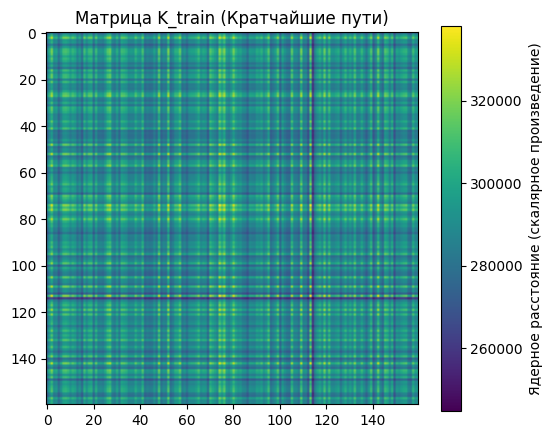

In [21]:
def shortest_path_kernel(train_graphs, test_graphs):
    max_path_len = 0
    for G in train_graphs:
        for source, dist_dict in nx.shortest_path_length(G):
            local_max = max(dist_dict.values())
            if local_max > max_path_len:
                max_path_len = local_max

    print(f"Максимальная длина кратчайшего пути в train: {max_path_len}")

    X_train = compute_sp_vectors(train_graphs, max_path_len)
    X_test = compute_sp_vectors(test_graphs, max_path_len)
    K_train = np.dot(X_train, X_train.T)
    K_test = np.dot(X_test, X_train.T)

    return K_train, K_test

K_train, K_test = shortest_path_kernel(train_graphs, test_graphs)

print(f"\nРазмер матрицы K_train: {K_train.shape}")
print(f"Размер матрицы K_test: {K_test.shape}")

plt.figure(figsize=(6, 5))
plt.imshow(K_train, cmap="viridis")
plt.colorbar(label="Ядерное расстояние (скалярное произведение)")
plt.title("Матрица K_train (Кратчайшие пути)")
plt.show()

## Обучение модели и метрики

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svc = SVC(kernel="precomputed", random_state=RANDOM_SEED)

param_grid = {"C": [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0, 10.0]}

grid_search = GridSearchCV(svc, param_grid, cv=5, scoring="accuracy")
grid_search.fit(K_train, y_train)

print(f"Наилучшие параметры после GridSearch: {grid_search.best_params_}")
print(f"Лучшая Accuracy на кросс-валидации: {grid_search.best_score_:.4f}")

best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(K_test)

print("\n=== Отчет о классификации на тестовой выборке ===")
print(classification_report(y_test, y_pred, target_names=["Erdos-Renyi (0)", "Barabasi-Albert (1)"]))

Наилучшие параметры после GridSearch: {'C': 0.01}
Лучшая Accuracy на кросс-валидации: 0.9563

=== Отчет о классификации на тестовой выборке ===
                     precision    recall  f1-score   support

    Erdos-Renyi (0)       1.00      0.80      0.89        20
Barabasi-Albert (1)       0.83      1.00      0.91        20

           accuracy                           0.90        40
          macro avg       0.92      0.90      0.90        40
       weighted avg       0.92      0.90      0.90        40



## Weisfeiler-Lehman Kernel

In [23]:
from collections import Counter
import hashlib


def wl_labeling_step(graphs, num_iterations=3):
    graph_labels = []
    for G in graphs:
        labels = {node: str(G.degree(node)) for node in G.nodes()}
        graph_labels.append(labels)

    all_graphs_feature_counts = [Counter(gl.values()) for gl in graph_labels]

    for h in range(1, num_iterations + 1):
        new_graph_labels = []

        for i, G in enumerate(graphs):
            current_labels = graph_labels[i]
            next_labels = {}

            for node in G.nodes():
                neighbor_labels = sorted(
                    [current_labels[neighbor] for neighbor in G.neighbors(node)]
                )

                aggregated_string = f"{current_labels[node]}-" + ",".join(
                    neighbor_labels
                )

                new_label = hashlib.md5(aggregated_string.encode()).hexdigest()
                next_labels[node] = new_label

            all_graphs_feature_counts[i].update(next_labels.values())
            new_graph_labels.append(next_labels)

        graph_labels = new_graph_labels

    return all_graphs_feature_counts


def weisfeiler_lehman_kernel(train_graphs, test_graphs, num_iterations=3):
    all_graphs = train_graphs + test_graphs
    feature_counts = wl_labeling_step(all_graphs, num_iterations=num_iterations)

    unique_features = set()
    for counts in feature_counts:
        unique_features.update(counts.keys())

    feature_to_idx = {feat: idx for idx, feat in enumerate(unique_features)}
    num_features = len(unique_features)
    print(f"Всего уникальных WL-признаков (размерность пространства): {num_features}")

    X_all = np.zeros((len(all_graphs), num_features))
    for i, counts in enumerate(feature_counts):
        for feat, count in counts.items():
            X_all[i, feature_to_idx[feat]] = count

    X_train_wl = X_all[: len(train_graphs)]
    X_test_wl = X_all[len(train_graphs) :]

    K_train_wl = np.dot(X_train_wl, X_train_wl.T)
    K_test_wl = np.dot(X_test_wl, X_train_wl.T)

    return K_train_wl, K_test_wl


K_train_wl, K_test_wl = weisfeiler_lehman_kernel(
    train_graphs, test_graphs, num_iterations=3
)

print(f"Размер WL K_train: {K_train_wl.shape}")
print(f"Размер WL K_test: {K_test_wl.shape}")

Всего уникальных WL-признаков (размерность пространства): 23490
Размер WL K_train: (160, 160)
Размер WL K_test: (40, 160)


## Обучение и метрики

In [24]:
svc_wl = SVC(kernel="precomputed", random_state=RANDOM_SEED)

param_grid_wl = {"C": [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0, 10.0, 100.0]}

grid_search_wl = GridSearchCV(svc_wl, param_grid_wl, cv=5, scoring="accuracy")
grid_search_wl.fit(K_train_wl, y_train)

print(f"Наилучшие параметры для WL: {grid_search_wl.best_params_}")
print(f"Лучшая Accuracy WL на кросс-валидации: {grid_search_wl.best_score_:.4f}")

y_pred_wl = grid_search_wl.best_estimator_.predict(K_test_wl)

print("\n=== Отчет о классификации (Weisfeiler-Lehman Kernel) ===")
print(
    classification_report(
        y_test, y_pred_wl, target_names=["Erdos-Renyi (0)", "Barabasi-Albert (1)"]
    )
)

Наилучшие параметры для WL: {'C': 1e-05}
Лучшая Accuracy WL на кросс-валидации: 1.0000

=== Отчет о классификации (Weisfeiler-Lehman Kernel) ===
                     precision    recall  f1-score   support

    Erdos-Renyi (0)       1.00      1.00      1.00        20
Barabasi-Albert (1)       1.00      1.00      1.00        20

           accuracy                           1.00        40
          macro avg       1.00      1.00      1.00        40
       weighted avg       1.00      1.00      1.00        40

